## Diabetes prediction ML Project

### Load Important Libraries

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Data Loading

In [38]:
df=pd.read_csv(r"C:\Users\HP\Desktop\ML_Project\diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


### Basic Understanding 

In [39]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [40]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [41]:
df.shape

(768, 9)

In [42]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [44]:
df.nunique()

Pregnancies                  17
Glucose                     136
BloodPressure                47
SkinThickness                51
Insulin                     186
BMI                         248
DiabetesPedigreeFunction    517
Age                          52
Outcome                       2
dtype: int64

### Data Cleaning

In [45]:
## Checked missing values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

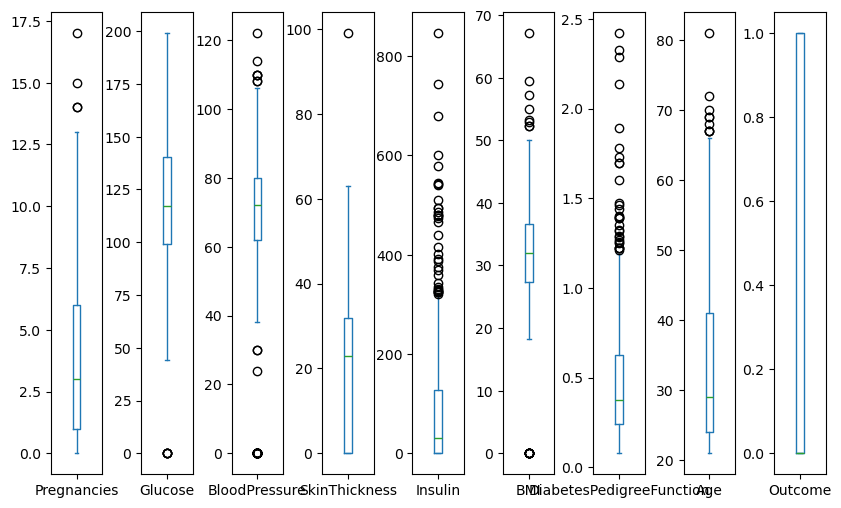

In [46]:
## check outlier
# boxplot
df.plot(kind="box",subplots=True,sharey=False,figsize=(10,6))
plt.subplots_adjust(wspace=0.75)
plt.show()

In [47]:
!pip install feature-engine

Access is denied.


Pregnancies                    Axes(0.125,0.11;0.0731132x0.77)
Glucose                     Axes(0.212736,0.11;0.0731132x0.77)
BloodPressure               Axes(0.300472,0.11;0.0731132x0.77)
SkinThickness               Axes(0.388208,0.11;0.0731132x0.77)
Insulin                     Axes(0.475943,0.11;0.0731132x0.77)
BMI                         Axes(0.563679,0.11;0.0731132x0.77)
DiabetesPedigreeFunction    Axes(0.651415,0.11;0.0731132x0.77)
Age                         Axes(0.739151,0.11;0.0731132x0.77)
Outcome                     Axes(0.826887,0.11;0.0731132x0.77)
dtype: object

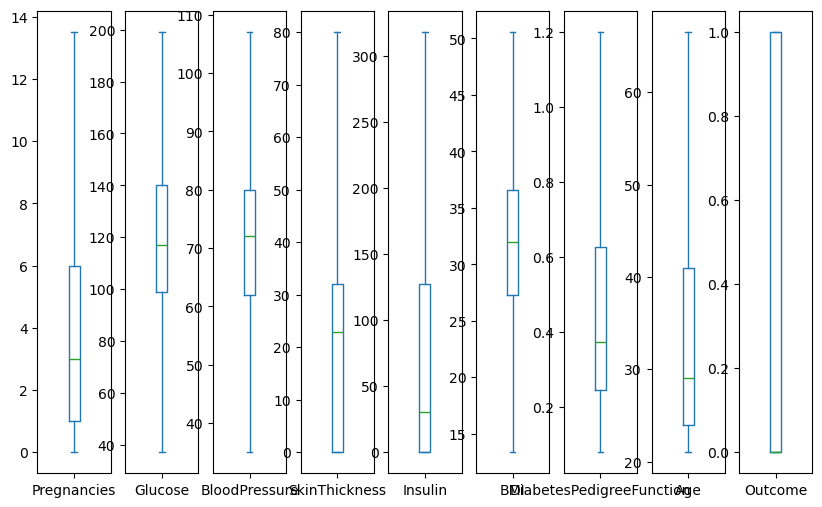

In [48]:
from feature_engine.outliers import Winsorizer
a= Winsorizer(capping_method="iqr",tail="both",fold=1.5,variables= None)
df=a.fit_transform(df)
df.plot(kind="box",subplots=True,sharey=False,figsize=(10,6))

### Data Visualization

### Scatter plot 

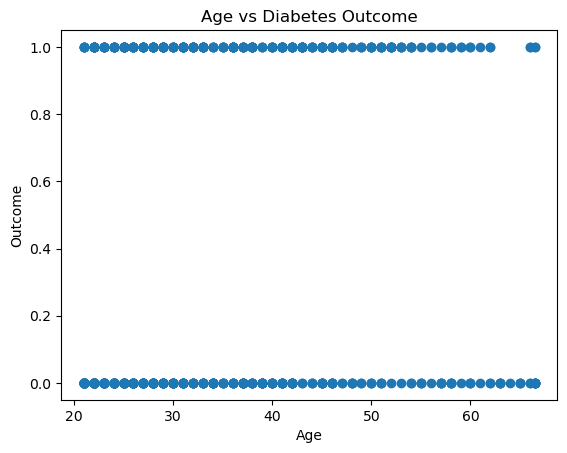

In [49]:
plt.scatter(df['Age'], df['Outcome'])
plt.xlabel('Age')
plt.ylabel('Outcome')
plt.title('Age vs Diabetes Outcome')
plt.show()

### Histogram

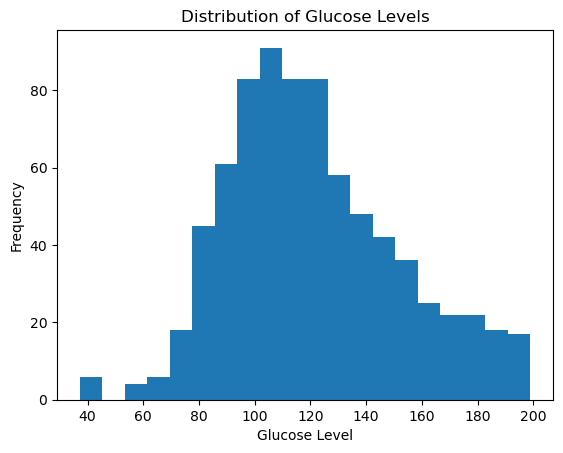

In [50]:
plt.hist(df['Glucose'], bins=20)
plt.xlabel('Glucose Level')
plt.ylabel('Frequency')
plt.title('Distribution of Glucose Levels')
plt.show()

### Correlation Heatmap

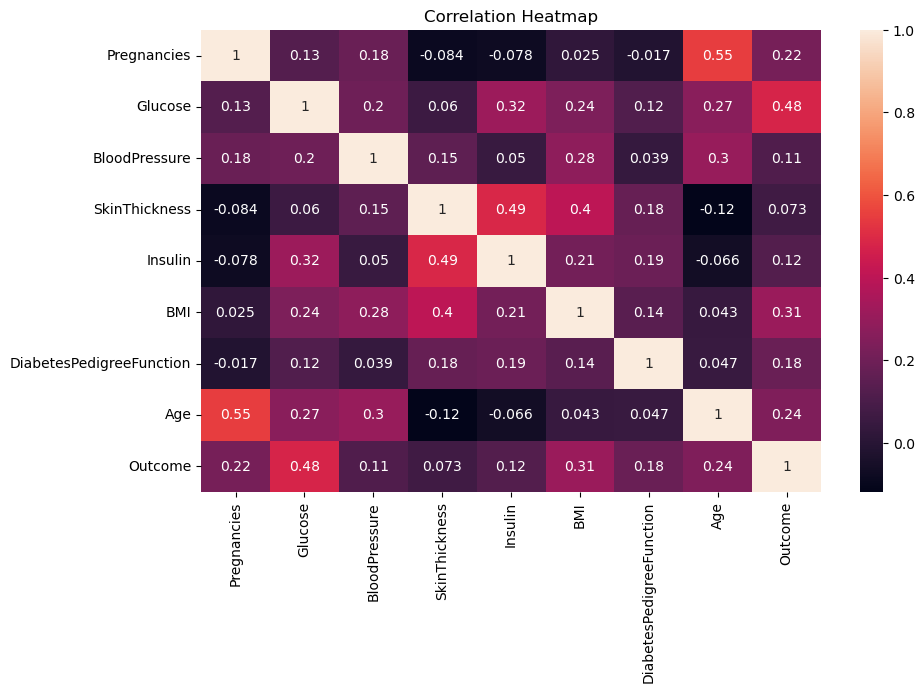

In [51]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

### Count Plot (Target Distribution)

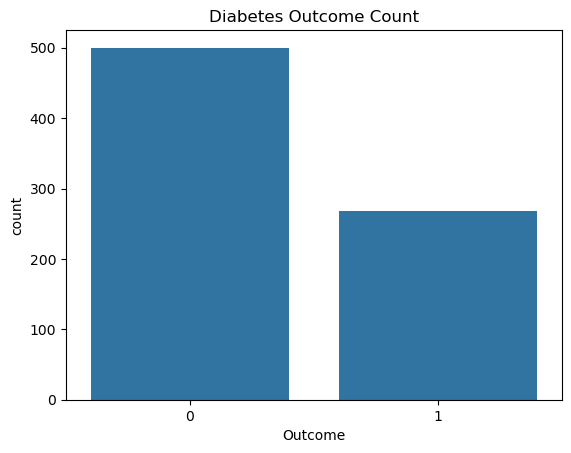

In [20]:
sns.countplot(x='Outcome', data=df)
plt.title('Diabetes Outcome Count')
plt.show()

In [21]:
## check value_counts of outcome bcz this is o/p
df.value_counts(df['Outcome'])

Outcome
0    500
1    268
Name: count, dtype: int64

In [22]:
## split data 
X =df.drop("Outcome",axis = 1)
y =df['Outcome']

### Model Building
##### Used basic ML algorithm (e.g., Logistic Regression)
##### Split data into training and testing

In [23]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split( X,y, test_size=0.2, random_state=42)

In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [25]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [26]:
## check prediction
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:,1]

In [27]:
from sklearn.metrics import confusion_matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[80 19]
 [19 36]]


In [28]:
from sklearn.metrics import classification_report

print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.81      0.81        99
           1       0.65      0.65      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



ROC-AUC Score: 0.814141414141414


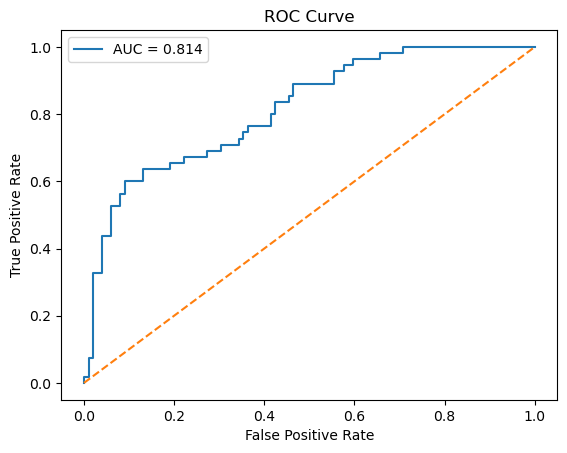

In [29]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predicted probabilities (IMPORTANT)
# The 'y_prob' variable from cell 'WFAHj-GUfNTo' was already computed successfully
# using the correctly fitted model and 'x_test'. We will use that.
# If you intend to recompute 'y_prob', ensure the 'model' is fitted and use 'x_test'.
# y_prob = model.predict_proba(X_test)[:, 1] # This line caused the error.

# ROC Curve values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC Score
auc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc_score)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random model line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

### Model Prediction

In [30]:
model.predict([[7,145,66,30,25,32.6,0.351,33]])

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1])

In [31]:
##check prediction
pregnancies = int(input("Enter Pregnancies: "))
glucose = int(input("Enter Glucose: "))
blood_pressure = int(input("Enter Blood Pressure: "))
skin_thickness = int(input("Enter Skin Thickness: "))
insulin = int(input("Enter Insulin: "))
bmi = float(input("Enter BMI: "))
dpf = float(input("Enter Diabetes Pedigree Function: "))
age = int(input("Enter Age: "))

# Convert input into array format for model
user_input = np.array([[pregnancies, glucose, blood_pressure, skin_thickness,
                        insulin, bmi, dpf, age]])

# Prediction
prediction = model.predict(user_input)
print(prediction)
if prediction[0] == 1:
    print("⚠️ The person is likely diabetes")
else:
    print("✅ The person is NOT diabetes")

Enter Pregnancies:  6
Enter Glucose:  123
Enter Blood Pressure:  45
Enter Skin Thickness:  25
Enter Insulin:  24
Enter BMI:  32.6
Enter Diabetes Pedigree Function:  0.345
Enter Age:  33


[0]
✅ The person is NOT diabetes


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


### Model Evaluation
##### Accuracy Score used to evaluate model

In [32]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.7532467532467533